Module to run the diffusion model (using Wavestitch)

In [1]:
"""import cell"""

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
from torch import device
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
import autoencoder as ae
from data_utils import Preprocessor
from training_utils import fetchModel
from utils import DimensionalityEstimator, Losses, get_frechet_distance, get_zscore_of_1D_or_2D_array, AutocorrMetrics

import fouad_wavestitch.training_and_saving_models as model_trainer
from fouad_wavestitch.training_and_saving_models import AutoencoderModel, DiffusionModel

"""get diffusion config params + set dataset"""
from fouad_wavestitch.param_extractor import dataset_name, ae_args, diffusion_args, LDM_args


Using device: cpu
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%


In [2]:
"""OLD Wavestitch"""

# np.random.seed(42)
# torch.manual_seed(42)
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset', '-d', type=str,
#                     help='MetroTraffic, BeijingAirQuality, AustraliaTourism, RossmanSales, PanamaEnergy', required=True)
# parser.add_argument('-backbone', type=str, help='Transformer, Bilinear, Linear, S4', default='S4')
# parser.add_argument('-beta_0', type=float, default=0.0001, help='initial variance schedule')
# parser.add_argument('-beta_T', type=float, default=0.02, help='last variance schedule')
# parser.add_argument('-timesteps', '-T', type=int, default=200, help='training/inference timesteps')
# parser.add_argument('-hdim', type=int, default=64, help='hidden embedding dimension')
# parser.add_argument('-lr', type=float, default=1e-4, help='learning rate')
# parser.add_argument('-batch_size', type=int, help='batch size', default=1024)
# parser.add_argument('-epochs', type=int, default=1000, help='training epochs')
# parser.add_argument('-layers', type=int, default=4, help='number of hidden layers')
# parser.add_argument('-window_size', type=int, default=32, help='the size of the training windows')
# parser.add_argument('-stride', type=int, default=1, help='the stride length to shift the training window by')
# parser.add_argument('-num_res_layers', type=int, default=4, help='the number of residual layers')
# parser.add_argument('-res_channels', type=int, default=64, help='the number of res channels')
# parser.add_argument('-skip_channels', type=int, default=64, help='the number of skip channels')
# parser.add_argument('-diff_step_embed_in', type=int, default=32, help='input embedding size diffusion')
# parser.add_argument('-diff_step_embed_mid', type=int, default=64, help='middle embedding size diffusion')
# parser.add_argument('-diff_step_embed_out', type=int, default=64, help='output embedding size diffusion')
# parser.add_argument('-s4_lmax', type=int, default=100)
# parser.add_argument('-s4_dstate', type=int, default=64)
# parser.add_argument('-s4_dropout', type=float, default=0.0)
# parser.add_argument('-s4_bidirectional', type=bool, default=True)
# parser.add_argument('-s4_layernorm', type=bool, default=True)
# parser.add_argument('-propCycEnc', type=bool, default=False)
# args = parser.parse_args()
# dataset = args.dataset
# device = device('cuda' if torch.cuda.is_available() else 'cpu')
# preprocessor = Preprocessor(dataset, args.propCycEnc)
# df = preprocessor.df_cleaned
# training_df = df.loc[preprocessor.train_indices]
# test_df = df.loc[preprocessor.test_indices]
# hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)
# # training_samples = []
# d_vals_tensor = from_numpy(training_df.values)
# training_samples = d_vals_tensor.unfold(0, args.window_size, 1).transpose(1, 2)
# # masks = m_vals_tensor.unfold(0, args.window_size, 1)
# # for i in range(0, len(training_df) - args.window_size + 1, args.stride):
# #     window = training_df.iloc[i:i + args.window_size].values
# #     training_samples.append(window)
# in_dim = len(training_df.columns)
# out_dim = len(training_df.columns) - len(hierarchical_column_indices)
# training_dataset = MyDataset(training_samples.float())
# model = fetchModel(in_dim, out_dim, args).to(device)
# diffusion_config = fetchDiffusionConfig(args)
# optimizer = optim.Adam(model.parameters(), lr=args.lr)
# criterion = nn.MSELoss()
# dataloader = DataLoader(training_dataset, batch_size=args.batch_size, shuffle=True)
# all_indices = np.arange(len(training_df.columns))

# # Find the indices not in the index_list
# remaining_indices = np.setdiff1d(all_indices, hierarchical_column_indices)

# # Convert to an ndarray
# non_hier_cols = np.array(remaining_indices)
# """TRAINING"""
# for epoch in range(args.epochs):
#     total_loss = 0.0
#     for batch in dataloader:
#         batch = batch.to(device)
#         timesteps = randint(diffusion_config['T'], size=(batch.shape[0],)).to(device)
#         sigmas = normal(0, 1, size=batch.shape).to(device)
#         """Forward noising"""
#         alpha_bars = diffusion_config['alpha_bars'].to(device)
#         coeff_1 = sqrt(alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         coeff_2 = sqrt(1 - alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         conditional_mask = np.ones(batch.shape)
#         conditional_mask[:, :, non_hier_cols] = 0
#         conditional_mask = from_numpy(conditional_mask).float().to(device)
#         batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
#         batch_noised = batch_noised.to(device)
#         timesteps = timesteps.reshape((-1, 1))
#         # timesteps = timesteps.to(device)
#         sigmas_predicted = model(batch_noised, timesteps)
#         optimizer.zero_grad()
#         sigmas_permuted = sigmas[:, :, non_hier_cols].permute((0, 2, 1))
#         sigmas_permuted = sigmas_permuted.to(device)
#         loss = criterion(sigmas_predicted, sigmas_permuted)
#         loss.backward()
#         total_loss += loss
#         optimizer.step()
#     print(f'epoch: {epoch}, loss: {total_loss}')
# path = f'saved_models/{args.dataset}/'
# if args.propCycEnc:
#     filename = "model_prop.pth"
# else:
#     filename = "model.pth"
# filepath = os.path.join(path, filename)

# if not os.path.exists(path):
#     os.makedirs(path)
# torch.save(model.state_dict(), filepath)


'OLD Wavestitch'

In [3]:
"""Data preprocessing (from training_wavestitch.py)"""

np.random.seed(diffusion_args.random_seed)
torch.manual_seed(diffusion_args.random_seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preprocessing (scales all data except for encoded features, then train-test splits it)
preprocessor= Preprocessor(dataset_name, diffusion_args.propCycEnc)
df          = preprocessor.df_cleaned
n_dim       = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Dataset dimensionality: {n_dim:.2f}")

training_df = df.loc[preprocessor.train_indices]
test_df     = df.loc[preprocessor.test_indices]

selected_cols = [0, 1] # cols to generate
cols_in_dataset=df.shape[1]
X_train       = training_df.iloc[:, selected_cols].values
X_test        = test_df.iloc[:, selected_cols].values

hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
train_dataset  = TensorDataset(X_tensor_train, X_tensor_train)
X_tensor_test  = torch.tensor(X_test, dtype=torch.float32)
test_dataset   = TensorDataset(X_tensor_test, X_tensor_test)

Dataset dimensionality: 4.04


In [4]:
"""Autoencoder training. Saves the model so no need to run this cell everytime"""

filepath = f"saved_models/autoencoder/{dataset_name}_autoencoder.pth"
if not os.path.exists(filepath):
    # Train and save
    trained_ae, best_loss, input_size= AutoencoderModel.train_autoencoder(train_dataset, test_dataset, ae_args, device)
    filepath                         = AutoencoderModel.save_autoencoder(trained_ae, dataset_name)
else:
    print("AE file exists")
    input_size = train_dataset[0][0].shape[0] # or load from saved config

# Load from disk
autoencoder = AutoencoderModel.load_autoencoder(filepath, input_size, ae_args, device)


AE file exists


input_mean tensor(0.0165)
recons mean tensor(0.1008)
AE loss (MSE): tensor(0.1305)
Autocorr diff: tensor(0.0557)
torch.Size([1757, 2])


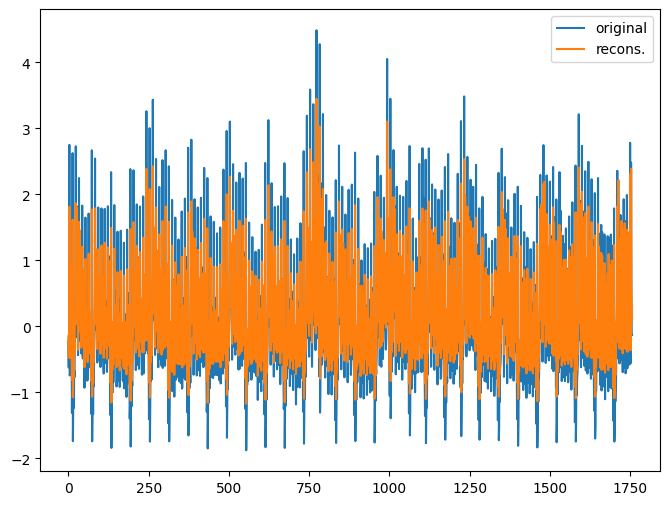

In [5]:
"""[sanity check] Apply AE latent-delatent to TEST dataset"""

loader = DataLoader(test_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)
autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input     = batch[0].to(device)
        latent_batch= autoencoder.encode_to_latent(x_input)
        x_output    = autoencoder.decode_from_latent(latent_batch)
        latents.append(latent_batch.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print("input_mean", torch.mean(X_input[:, selected_cols]))
print("recons mean", torch.mean(reconstructed[:, selected_cols]))

mse_val = Losses.compute_MSE_loss(X_input[:, selected_cols], reconstructed[:, selected_cols])
print("AE loss (MSE):",mse_val)

autocorr_error = AutocorrMetrics.autocorr_diff(X_input[:, selected_cols], reconstructed[:, selected_cols], lag=20)
print("Autocorr diff:", autocorr_error)

print(X_input.shape)

variate_to_plot = 1
plt.figure(figsize=(8, 6))
plt.plot(X_input[:, variate_to_plot], label='original')
plt.plot(reconstructed[:, variate_to_plot], label='recons.')
plt.legend()
plt.show()


In [6]:
"""Training wavestitch diffusion on TRAIN set (from training_wavestitch.py)"""

# changed S4model.py > SSKernelNPLR.register to load the model
# Train and save

# model, total_loss, in_dim, out_dim= DiffusionModel.train_diffusion(training_df, hierarchical_column_indices, diffusion_args, device)
# filepath                          = DiffusionModel.save_diffusion_model(model, dataset_name, diffusion_args)

filepath = f"saved_models/{dataset_name}/"
filename = "model_prop.pth" if diffusion_args.propCycEnc else "model.pth"
full_path = os.path.join(filepath, filename)

if not os.path.exists(full_path):
    model, total_loss, in_dim, out_dim = DiffusionModel.train_diffusion(training_df, hierarchical_column_indices, diffusion_args, device)
    DiffusionModel.save_diffusion_model(model, dataset_name, diffusion_args)
else:
    in_dim  = training_df.shape[1]
    out_dim = in_dim - len(hierarchical_column_indices)
    print("Diffusion model already there")

# Load
model = DiffusionModel.load_diffusion_model(full_path, in_dim, out_dim, diffusion_args, device)


Diffusion model already there


In [7]:
# # Synthesize samples using terminal version
# !python wavestitch_synthesizer.py -dataset RossmanSales -synth_mask C


In [8]:
"""Synthesize samples on TEST set [from wavestitch_synthesizer.py]"""

# synth = model_trainer.Synthesizer(df, preprocessor, diffusion_args, dataset_name)
# synth_df_out, exec_times = synth.synthesize(n_trials=diffusion_args.n_trials)

# suffix = 'cycProp' if diffusion_args.propCycEnc else 'cycStd'
# with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_{suffix}.txt', 'a') as f:
#     arr_time = np.array(exec_times)
#     f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))
# ======================

model_path = f"saved_models/{dataset_name}/"
filename   = "model_prop.pth" if diffusion_args.propCycEnc else "model.pth"
full_model_path = os.path.join(model_path, filename)

# Train if model not found
if not os.path.exists(full_model_path):
    model, total_loss, in_dim, out_dim = DiffusionModel.train_diffusion(training_df, hierarchical_column_indices, diffusion_args, device)
    DiffusionModel.save_diffusion_model(model, dataset_name, diffusion_args)

# Synthesize
synth = model_trainer.Synthesizer(df, preprocessor, diffusion_args, dataset_name)
synth_df_out, exec_times = synth.synthesize(n_trials=diffusion_args.n_trials)

# Save timing stats
suffix = 'cycProp' if diffusion_args.propCycEnc else 'cycStd'
with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_{suffix}.txt', 'a') as f:
    arr_time = np.array(exec_times)
    f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


File 1/1 done


In [9]:
# """Synthesize samples on TEST set [from wavestitch_synthesizer.py]"""

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Helper ---
# def decimal_places(series):
#     return series.apply(lambda x: len(str(x).split('.')[1]) if '.' in str(x) else 0).max()

# def create_pipelined_noise(batch_shape, device, window_size, stride):
#     # avoid passing test_batch directly for noise creation
#     total_rows = stride * (batch_shape[0]-1) + window_size
#     sampled    = torch.normal(0, 1, (total_rows, batch_shape[2])).to(device)
#     return sampled.unfold(0, window_size, stride).transpose(1, 2)

# # --- Load Data ---
# np.random.seed(diffusion_args.random_seed)
# torch.manual_seed(diffusion_args.random_seed)

# end_indices       = preprocessor.test_indices[-1]
# start_indices     = preprocessor.test_indices[0]
# window_count      = ((end_indices + 1 - diffusion_args.window_size - start_indices) // diffusion_args.stride) + 1
# tilde_start       = end_indices + 1 - diffusion_args.window_size - (window_count * diffusion_args.stride)
# additional_indices= start_indices - tilde_start
# # tweaking test_df to add more context to it
# test_df           = df.loc[preprocessor.train_indices[-additional_indices:] + preprocessor.test_indices]
# test_df_with_hierarchy = preprocessor.cyclicDecode(test_df)
# decimal_accuracy  = {k: decimal_places(preprocessor.df_orig[k])
#                      for k in test_df_with_hierarchy.columns}
# metadata          = test_df_with_hierarchy[preprocessor.hierarchical_features_uncyclic]
# rows_to_synth     = metadataMask(metadata, diffusion_args.synth_mask, dataset_name)
# real_df           = test_df_with_hierarchy[rows_to_synth]
# df_synth          = test_df.copy()

# # --- Model Prep ---
# data_tensor = from_numpy(df_synth.values)
# mask_tensor = from_numpy(rows_to_synth.values)
# windows     = data_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride).transpose(1, 2)
# masks       = mask_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride)
# hierarchical_column_indices = df_synth.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

# non_hier_cols   = np.setdiff1d(np.arange(len(df_synth.columns)), hierarchical_column_indices)
# test_dataset    = MyDataset(windows.float())
# mask_dataset    = MyDataset(masks)
# model           = fetchModel(len(df_synth.columns), len(non_hier_cols), diffusion_args).to(device)
# diffusion_config= fetchDiffusionConfig(diffusion_args)
# test_loader     = DataLoader(test_dataset, batch_size=diffusion_args.diff_batch_size)
# mask_loader     = DataLoader(mask_dataset, batch_size=diffusion_args.diff_batch_size)
# model_path      = f'saved_models/{dataset_name}/model_prop.pth' if diffusion_args.propCycEnc else f'saved_models/{dataset_name}/model.pth'
# saved_params    = torch.load(model_path, map_location=device)

# model.load_state_dict(saved_params)
# for param in model.parameters():
#     param.requires_grad = False
# model.eval()

# real_df_out = preprocessor.rescale(real_df).reset_index(drop=True).round(decimal_accuracy)
# path        = f'generated/{dataset_name}/{diffusion_args.synth_mask}/'
# os.makedirs(path, exist_ok=True)
# real_path   = os.path.join(path, 'real.csv')
# if not os.path.exists(real_path):
#     real_df_out.to_csv(real_path)

# # --- Inference ---
# @torch.no_grad()
# def synthesize_samples(input_dataset, n_trials, device, test_loader, mask_loader, stride, window_size, hierarchical_column_indices, 
#                        diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, propCycEnc, path):
#     """Wavestitch conditional synthesis, and writes to csv file for eacn trial
#     - synth_df_out: is SCALED back using the original scaling of df"""
#     num_ops    = 0
#     exec_times = []
#     for trial in range(n_trials):
#         start_time   = timer()
#         synth_tensor = torch.empty(0, input_dataset.inputs.shape[2]).to(device)
#         for idx, (test_batch, mask_batch) in enumerate(zip(test_loader, mask_loader)):
#             test_batch = test_batch.to(device)
#             mask_batch = mask_batch.to(device)
#             noise = create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#             x    = noise.clone()
#             x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
#             # for step in range(diffusion_config['T'] - 1, -1, -1):
#             for step in reversed(range(diffusion_config['T'])):
#                 times = torch.full((test_batch.shape[0], 1), step).to(device)
#                 ab_t  = diffusion_config['alpha_bars'][step].to(device)
#                 ab_t1 = diffusion_config['alpha_bars'][step - 1].to(device) if step > 0 else None
#                 at    = diffusion_config['alphas'][step].to(device)
#                 b_t   = diffusion_config['betas'][step].to(device)
#                 sampled_noise= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#                 cached       = torch.sqrt(ab_t) * test_batch + torch.sqrt(1 - ab_t) * sampled_noise
#                 mask_expanded= torch.zeros_like(test_batch, dtype=bool)
#                 for c in non_hier_cols:
#                     mask_expanded[:, :, c] = mask_batch
#                 x[~mask_expanded] = cached[~mask_expanded]
#                 x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
#                 eps = model(x, times)
#                 eps = eps.permute(0, 2, 1)
#                 variance = 0.0
#                 if step > 0:
#                     variance = b_t * ((1 - ab_t1) / (1 - ab_t)) * torch.normal(0, 1, size=eps.shape).to(device)
#                 norm_denoised= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#                 norm_denoised[:, :, non_hier_cols] = (x[:, :, non_hier_cols] - ((b_t / torch.sqrt(1 - ab_t)) * eps)) / torch.sqrt(at)
#                 norm_denoised[:, :, non_hier_cols] += variance
#                 x[mask_expanded]  = norm_denoised[mask_expanded]
#                 x[~mask_expanded] = test_batch[~mask_expanded]
#                 # we use 1: in line below and not 0: because 0 has no predecessor window to copy from
#                 x[1:, : (window_size - stride), :] = x.roll(1, 0)[1:, stride: window_size, :]
#                 if trial == 0:
#                     num_ops += 1
#             if idx == 0:
#                 generated = torch.cat((x[0], x[1:, (window_size - stride):, :].reshape(-1, x.shape[2])), dim=0)
#             else:
#                 generated = x[:, (window_size - stride):, :].reshape(-1, x.shape[2])
#             synth_tensor  = torch.cat((synth_tensor, generated), dim=0)

#         exec_times.append(timer() - start_time)
#         df_synthesized = pd.DataFrame(synth_tensor.cpu().numpy(), columns=df.columns)
#         # synth_df_out   = preprocessor.decode(df_synthesized, rescale=True)[rows_to_synth.reset_index(drop=True)].round(decimal_accuracy)
#         mask         = rows_to_synth.to_numpy() if hasattr(rows_to_synth, "to_numpy") else np.array(rows_to_synth)
#         # un-scale
#         synth_df_out = preprocessor.decode(df_synthesized, rescale=True)[mask].round(decimal_accuracy)
#         file_suffix  = 'cycProp' if propCycEnc else 'cycStd'
#         synth_df_out.to_csv(f'{path}synth_hyacinth_pipeline_stride_{stride}_trial_{trial}_{file_suffix}.csv')
#         print(f"File {trial+1}/{n_trials} done")
#         if trial == 0:
#             with open(f'{path}denoiser_calls_pipeline_stride_{stride}_{file_suffix}.txt', 'w') as f:
#                 f.write(str(num_ops))
#     return synth_df_out, exec_times

# synth_df_out, exec_times= synthesize_samples(test_dataset, diffusion_args.n_trials, device, test_loader, mask_loader, diffusion_args.stride, diffusion_args.window_size, hierarchical_column_indices, 
#                                              diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, diffusion_args.propCycEnc, path)

# with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_cycStd.txt', 'a') as f:
#     arr_time = np.array(exec_times)
#     f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


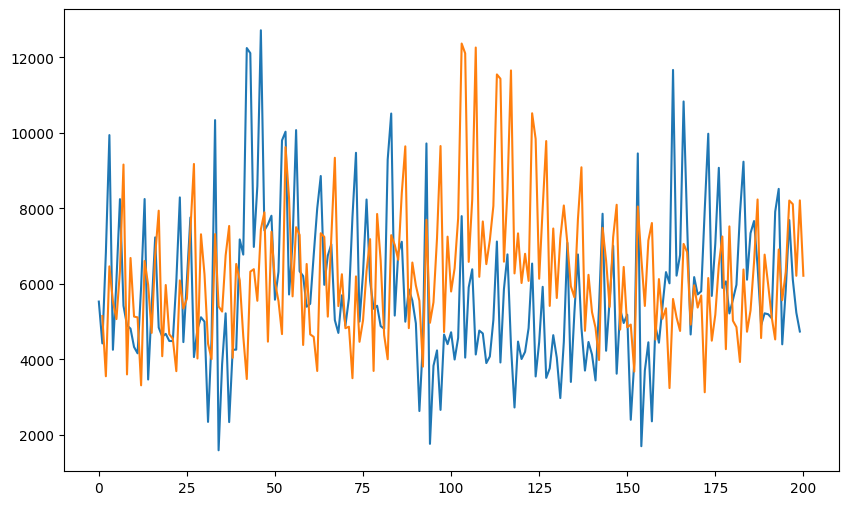

AE loss (MSE): tensor(1.3049)


In [10]:
# synthesized output

df_rescaled = preprocessor.decode(df, rescale=True)

plt.figure(figsize=(10, 6))  # width=10 inches, height=4 inches
plt.plot(df_rescaled.iloc[:200, 0])
plt.plot(synth_df_out.iloc[:200, 0])
plt.show()

# Get MSE (on standard scaled set)
scaler     = StandardScaler()
df1_scaled = scaler.fit_transform(df_rescaled.iloc[:, selected_cols])
df2_scaled = scaler.transform(synth_df_out.iloc[:, selected_cols])

array1 = torch.tensor(df1_scaled, dtype=torch.float32)
array2 = torch.tensor(df2_scaled, dtype=torch.float32)

min_len = min(array1.shape[0], array2.shape[0])
mse_val = Losses.compute_MSE_loss(array1[:min_len], array2[:min_len])
print("AE loss (MSE):", mse_val)

In [11]:
print(synth_df_out.mean())
# n_trial = 5
# Sales        8111.763802
# Customers     951.133751

# n_trial = 2
# Sales        7689.264087
# Customers     892.767217

# n_trial = 1
# Sales        7599.594764
# Customers     885.080250


Sales        7122.603870
Customers     639.653956
Year         2015.000000
Month           4.019351
Day            15.997723
Store           5.501992
dtype: float64


In [17]:
"""LDM"""

# def run_ldm_synthesis(autoencoder, diffusion_args, dataset_name, training_df, hierarchical_column_indices, device):
#     # Load AE (trained on selected columns only)
#     ae_path = f"saved_models/autoencoder/{dataset_name}_autoencoder.pth"
#     autoencoder = AutoencoderModel.load_autoencoder(
#         ae_path, input_size=autoencoder.input_size, ae_args=autoencoder.ae_args, device=device)
#     autoencoder.eval()

#     # Prepare latent training data by encoding original data
#     with torch.no_grad():
#         X = torch.tensor(training_df.values, dtype=torch.float32).to(device)
#         latent_train = autoencoder.encode_to_latent(X).cpu().numpy()
#     latent_df = pd.DataFrame(latent_train)

#     # Train or load diffusion model on latent space
#     model_path = f"saved_models/{dataset_name}/"
#     filename = "model_prop.pth" if diffusion_args.propCycEnc else "model.pth"
#     full_model_path = os.path.join(model_path, filename)

#     if not os.path.exists(full_model_path):
#         model, total_loss, in_dim, out_dim = DiffusionModel.train_diffusion(
#             latent_df, hierarchical_column_indices, diffusion_args, device)
#         DiffusionModel.save_diffusion_model(model, dataset_name, diffusion_args)
#     else:
#         in_dim = latent_df.shape[1]
#         out_dim = in_dim - len(hierarchical_column_indices)
#         model = DiffusionModel.load_diffusion_model(full_model_path, in_dim, out_dim, diffusion_args, device)
#     model.eval()

#     # Synthesize latent samples with diffusion model
#     synth = model_trainer.Synthesizer(latent_df, None, diffusion_args, dataset_name, model=model, autoencoder=autoencoder)
#     latent_synth_out, exec_times = synth.synthesize(n_trials=diffusion_args.n_trials)

#     # Decode latent outputs to original data space
#     with torch.no_grad():
#         latent_tensor = torch.tensor(latent_synth_out, dtype=torch.float32).to(device)
#         decoded_tensor = autoencoder.decode_from_latent(latent_tensor)
#     decoded_np = decoded_tensor.cpu().numpy()
#     generated_df = pd.DataFrame(decoded_np, columns=training_df.columns)
#     return generated_df, exec_times

# ===========================
# NOTE: SSSDS4_diffusion.py > SSSDS4Imputer class > forward() has an issue with permuting tuples
# TODO: there is a .permute(0, 2, 1) in forward(), which forces us to use .permute() everywhere we call the function

ldm_trainer = model_trainer.LDMTrainer(autoencoder, LDM_args, dataset_name, device)

# 2. Train and Save the model
filepath, total_train_loss, total_test_loss, in_dim, out_dim, latent_dim = ldm_trainer.train_and_save_model(
    training_df, test_df, hierarchical_column_indices) # hierarchical_column_indices can be None or an actual list if needed
diffusion_config = ldm_trainer.diffusion_config

# 3. Load LDM (directly from the trainer instance or load from saved path)
LDM_model = ldm_trainer.LDM_model
LDM_model.eval()
print("LDM model loaded and ready for use.")

# 4. sampling
z_T = torch.randn((LDM_args.num_samples, latent_dim, 1), device=device)
x   = z_T
LDM_model.eval()
with torch.no_grad():
    for t_step in reversed(range(diffusion_config['T'])):
        t         = torch.full((LDM_args.num_samples, 1), t_step, device=device, dtype=torch.long)        
        eps       = LDM_model(x.permute(0, 2, 1), t)
        alpha_bar = ldm_trainer.diffusion_config['alpha_bars'][t_step].to(device)
        alpha     = ldm_trainer.diffusion_config['alphas'][t_step].to(device)
        beta      = ldm_trainer.diffusion_config['betas'][t_step].to(device)        
        if t_step > 0:
            noise = torch.randn_like(x) # Consistent shape (N, L_dim, 1)
        else:
            noise = 0
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * noise

latent_repr    = x.mean(dim=-1)
latent_repr_np = latent_repr.cpu().numpy()
fitted_scaler  = ldm_trainer.get_latent_scaler()
inverse_scaled_latent_repr_np = fitted_scaler.inverse_transform(latent_repr_np)
decoded_tensor = autoencoder.decode_from_latent(torch.tensor(inverse_scaled_latent_repr_np, dtype=torch.float32).to(device))
decoded_np     = decoded_tensor.detach().cpu().numpy()
generated_df   = pd.DataFrame(decoded_np, columns=training_df.columns)


Scaled Latent samples (training): torch.Size([6063, 2, 1])
Scaled Latent samples (test): torch.Size([1757, 2, 1])
Starting LDM training...
Epoch: 20/150, Avg Epoch Loss: 0.5310
Epoch: 40/150, Avg Epoch Loss: 0.5314
Epoch: 60/150, Avg Epoch Loss: 0.5211
Epoch: 80/150, Avg Epoch Loss: 0.5227
Epoch: 100/150, Avg Epoch Loss: 0.5173
Epoch: 120/150, Avg Epoch Loss: 0.5136
Epoch: 140/150, Avg Epoch Loss: 0.5001
Starting LDM evaluation...
Test Loss: 0.8734
LDM Training complete. Final Training Loss: 0.5356, Final Test Loss: 0.8734
LDM model saved to: saved_models/RossmanSales/latent_model.pth
LDM model loaded and ready for use.


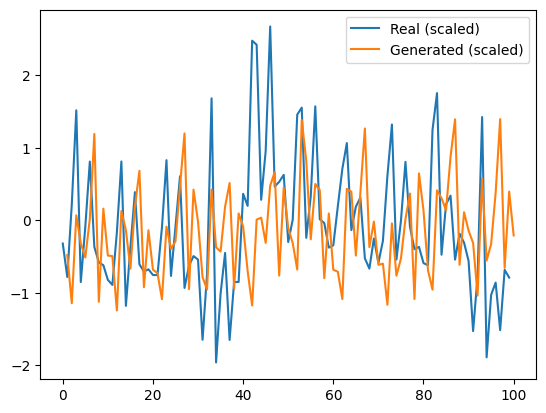

MSE (scaled selected cols): 1.304874


In [ ]:
selected_col_names = df.columns[selected_cols]

# Use the preprocessor's scaler to scale generated data (only selected cols)
synth_scaled_vals= preprocessor.scaler.transform(synth_df_out[selected_col_names])
synth_scaled     = pd.DataFrame(synth_scaled_vals, columns=selected_col_names, index=synth_df_out.index)

# Plot example: first selected col, scaled real vs scaled generated
plt.plot(training_df[selected_col_names].iloc[:100][selected_col_names[0]], label='Real (scaled)')
plt.plot(synth_scaled.iloc[:100][selected_col_names[0]], label='Generated (scaled)')
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    training_df[selected_col_names].iloc[:len(synth_scaled)][selected_col_names],
    synth_scaled[selected_col_names])
# array1 = training_df[selected_col_names].iloc[:len(synth_scaled)][selected_col_names]
# array2 = synth_scaled[selected_col_names]
# mse = Losses.compute_MSE_loss(array1, array2)

print(f"MSE (scaled selected cols): {mse:.6f}")


tensor(-0.0048)
tensor(0.0860)
MSE tensor(0.1276)


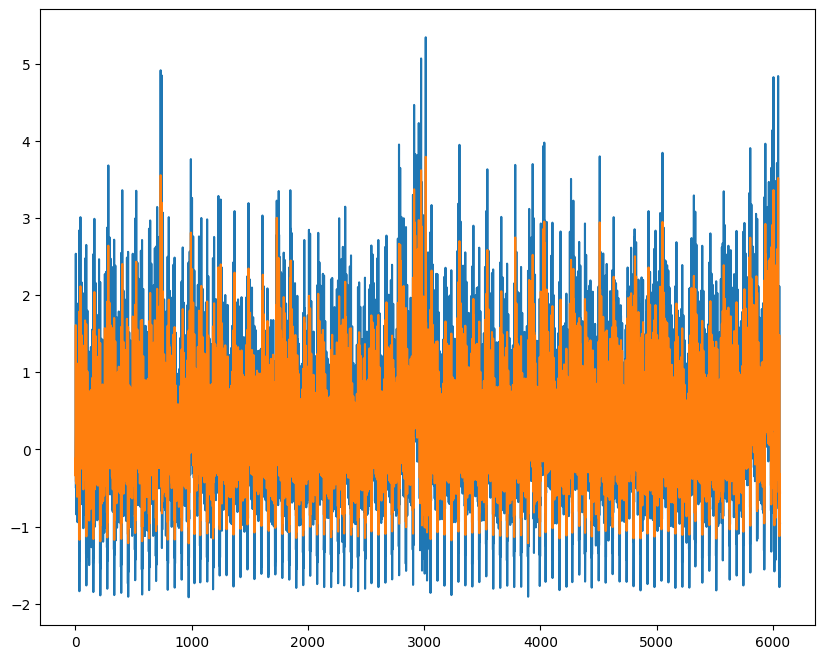

In [14]:
"""[OLD] LDM"""

training_df_tensor = torch.tensor(training_df.values, dtype=torch.float32).to(device)
latent_features    = autoencoder.encode_to_latent(x_input)
# %%%%%%%%%%%%%%%%%%
@torch.no_grad()
def latent_synthesize_samples(input_dataset, n_trials, device, test_loader, model, autoencoder, diffusion_config):
    for trial in range(n_trials):
        synth_latent = torch.empty(0, latent_dim).to(device)
        for test_batch in test_loader:
            test_batch = test_batch.to(device)
            latent_batch = autoencoder.encode_to_latent(test_batch)
            noise = torch.normal(0, 1, latent_batch.shape).to(device)
            x = noise.clone()

            for step in reversed(range(diffusion_config['T'])):
                times = torch.full((latent_batch.shape[0], 1), step).to(device)
                # diffusion update on latent x here
                eps = model(x, times)
                # denoise x according to diffusion equation in latent space

            synth_latent = torch.cat((synth_latent, x), dim=0)

        x_output = autoencoder.decode_from_latent(synth_latent)
        # Save or return x_output as synthesized samples
    return x_output
# %%%%%%%%%%%%%%%%%

x_output= autoencoder.decode_from_latent(latent_features)

# =========================================================
ae_dataset = train_dataset #val_dataset # 
loader     = DataLoader(ae_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print(torch.mean(X_input))
print(torch.mean(reconstructed))
mse_val = Losses.compute_MSE_loss(X_input[:, selected_cols], reconstructed[:, selected_cols])
print("MSE", mse_val)

variate_to_plot = 1
plt.figure(figsize=(10, 8))  # width=10 inches, height=4 inches
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])
plt.show()


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Prepare data
X_real = df.values.astype(np.float32)

# Split real data
X_train, X_val = train_test_split(X_real, test_size=0.2, random_state=42)

# Full scaler fit on training data only
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)

# Prepare training tensor and loader (similar to your current code)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, torch.zeros(len(X_train_tensor)))
train_loader = DataLoader(train_dataset, batch_size=ae_args.ae_batch_size, shuffle=True)

# AE setup and training
autoencoder = ae.Autoencoder(input_size=X_train.shape[1],
                             layer1_dim=ae_args.ae_layer1_dim,
                             layer2_dim=ae_args.ae_layer2_dim,
                             latent_dim=ae_args.ae_latent_dim,
                             dropout_prob=ae_args.ae_dropout_prob).to(device)
optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=ae_args.ae_optimizer_lr,
                              weight_decay=ae_args.ae_weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode=ae_args.ae_scheduler_mode,
                                                       patience=ae_args.ae_scheduler_patience,
                                                       factor=ae_args.ae_scheduler_factor)

trainer = ae.TrainAutoencoder()
trainer.train_autoencoder(device, autoencoder, ae_args.ae_training_epochs,
                          train_loader, optimizer, scheduler,
                          validation_loader=None,
                          patience=ae_args.ae_training_patience)

# --- Now evaluate any synth df ---

def evaluate_synth_df(ae, scaler_full, X_val, synth_df, selected_cols, device):
    from sklearn.preprocessing import StandardScaler

    # Scale selected cols of real val independently
    scaler_real = StandardScaler()
    X_val_selected_scaled = scaler_real.fit_transform(X_val[:, selected_cols])

    # Scale synth selected cols independently
    scaler_synth = StandardScaler()
    synth_vals = synth_df.values.astype(np.float32)[:len(X_val), selected_cols]
    X_synth_selected_scaled = scaler_synth.fit_transform(synth_vals)

    # Create scaled full arrays by replacing selected cols with scaled data
    X_val_scaled = X_val.copy()
    X_val_scaled[:, selected_cols] = X_val_selected_scaled

    # X_synth_scaled = synth_df.values.astype(np.float32)[:len(X_val)].copy()
    # X_synth_scaled = X_val.copy()
    # X_synth_scaled[:, selected_cols] = X_synth_selected_scaled

    X_synth_scaled = np.zeros_like(X_val)
    X_synth_scaled[:, selected_cols] = X_synth_selected_scaled

    # Apply full scaler to both
    X_val_scaled_full = scaler_full.transform(X_val_scaled)
    X_synth_scaled_full = scaler_full.transform(X_synth_scaled)

    # Convert to tensors
    X_val_tensor = torch.tensor(X_val_scaled_full, dtype=torch.float32).to(device)
    X_synth_tensor = torch.tensor(X_synth_scaled_full, dtype=torch.float32).to(device)

    # Extract latents
    ae.eval()
    with torch.no_grad():
        real_latents = ae.encode_to_latent(X_val_tensor).cpu().numpy()
        synth_latents = ae.encode_to_latent(X_synth_tensor).cpu().numpy()

    # Scale latents
    scaler_latent = StandardScaler()
    real_latents_scaled = scaler_latent.fit_transform(real_latents)
    synth_latents_scaled = scaler_latent.transform(synth_latents)

    # Compute FID
    FID_distance = get_frechet_distance(real_latents_scaled, synth_latents_scaled)

    # Compute z-score on selected cols scaled
    z_mean, z_std = get_zscore_of_1D_or_2D_array(X_val_selected_scaled, X_synth_selected_scaled, num_samples=100)

    print(f"FID: {FID_distance}")
    print(f"z-score mean: {z_mean}")
    print(f"z-score std: {z_std}")
    return FID_distance, z_mean, z_std

selected_cols_central = list(range(min(df.shape[1], synth_df_out.shape[1])))
FID, zmean, zstd = evaluate_synth_df(autoencoder, scaler_full, X_val, synth_df_out, selected_cols_central, device)
print("central:", FID, zmean, zstd)

selected_cols_ldm = list(range(min(df.shape[1], ldm_synth_df_out.shape[1])))
LDM_FID, LDM_zmean, LDM_zstd = evaluate_synth_df(autoencoder, scaler_full, X_val, ldm_synth_df_out, selected_cols_ldm, device)
print("LDM:", LDM_FID, LDM_zmean, LDM_zstd)
# ===================
# # Prepare data
# X_real  = df.values.astype(np.float32)
# X_synth = synth_df_out.values.astype(np.float32)

# # Split real data
# X_train, X_val = train_test_split(X_real, test_size=0.2, random_state=42)

# # Select columns for scaling
# selected_cols = list(range(X_synth.shape[1]))

# # Scale selected cols of real val independently
# scaler_real = StandardScaler()
# X_val_selected_scaled = scaler_real.fit_transform(X_val[:, selected_cols])

# # Scale synth cols independently
# scaler_synth = StandardScaler()
# X_synth_selected_scaled = scaler_synth.fit_transform(X_synth[:len(X_val), selected_cols])

# # Create scaled full arrays by replacing selected cols with scaled data
# X_val_scaled = X_val.copy()
# X_val_scaled[:, selected_cols] = X_val_selected_scaled

# X_synth_scaled = X_val.copy()
# X_synth_scaled[:, selected_cols] = X_synth_selected_scaled

# # Scale full training data with StandardScaler for AE training
# scaler_full = StandardScaler()
# X_train_scaled = scaler_full.fit_transform(X_train)

# print("Real val selected cols scaled min/max:", X_val_selected_scaled.min(), X_val_selected_scaled.max())
# print("Synth selected cols scaled min/max:", X_synth_selected_scaled.min(), X_synth_selected_scaled.max())

# # Prepare tensors and datasets
# X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
# X_val_tensor   = torch.tensor(scaler_full.transform(X_val_scaled), dtype=torch.float32)
# X_synth_tensor = torch.tensor(scaler_full.transform(X_synth_scaled), dtype=torch.float32).to(device)

# train_dataset = TensorDataset(X_train_tensor, torch.zeros(len(X_train_tensor)))
# val_dataset   = TensorDataset(X_val_tensor, torch.zeros(len(X_val_tensor)))

# train_loader = DataLoader(train_dataset, batch_size=ae_args.ae_batch_size, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

# # AE setup and training (same as before)
# autoencoder = ae.Autoencoder(input_size=X_train_tensor.shape[1],
#                              layer1_dim=ae_args.ae_layer1_dim,
#                              layer2_dim=ae_args.ae_layer2_dim,
#                              latent_dim=ae_args.ae_latent_dim,
#                              dropout_prob=ae_args.ae_dropout_prob).to(device)
# optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=ae_args.ae_optimizer_lr,
#                               weight_decay=ae_args.ae_weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode=ae_args.ae_scheduler_mode,
#                                                        patience=ae_args.ae_scheduler_patience,
#                                                        factor=ae_args.ae_scheduler_factor)

# trainer = ae.TrainAutoencoder()
# trainer.train_autoencoder(device, autoencoder, ae_args.ae_training_epochs,
#                           train_loader, optimizer, scheduler,
#                           validation_loader=val_loader,
#                           patience=ae_args.ae_training_patience)

# # Extract latents
# autoencoder.eval()
# with torch.no_grad():
#     real_latents = autoencoder.encode_to_latent(X_val_tensor.to(device)).cpu().numpy()
#     synth_latents = autoencoder.encode_to_latent(X_synth_tensor.to(device)).cpu().numpy()

# # Scale latents before FID
# scaler_latent = StandardScaler()
# real_latents_scaled = scaler_latent.fit_transform(real_latents)
# synth_latents_scaled = scaler_latent.transform(synth_latents)

# FID_distance = get_frechet_distance(real_latents_scaled, synth_latents_scaled)
# print("FID:", FID_distance)

# # z-score on scaled selected columns (real vs synth)
# z_mean, z_std = get_zscore_of_1D_or_2D_array(X_val_selected_scaled, X_synth_selected_scaled, num_samples=100)
# print("z-score mean:", z_mean)
# print("z-score std:", z_std)

Epoch [25/150], training loss: 0.7503
Epoch [50/150], training loss: 0.7180
Epoch [75/150], training loss: 0.7011
Epoch [100/150], training loss: 0.6960
Epoch [125/150], training loss: 0.6952
Epoch [150/150], training loss: 0.6934
FID: 0.23781101330374788
z-score mean: 0.09260825783130713
z-score std: 0.9553466936049078
central: 0.23781101330374788 0.09260825783130713 0.9553466936049078
FID: 0.23849725435128333
z-score mean: 0.11557755187386647
z-score std: 0.8783309269824561
LDM: 0.23849725435128333 0.11557755187386647 0.8783309269824561


In [16]:
print(np.min(X_synth), np.max(X_synth))
print(np.min(X_val[:, selected_cols]), np.max(X_val[:, selected_cols]))

NameError: name 'X_synth' is not defined

t-SNE done.
UMAP done.


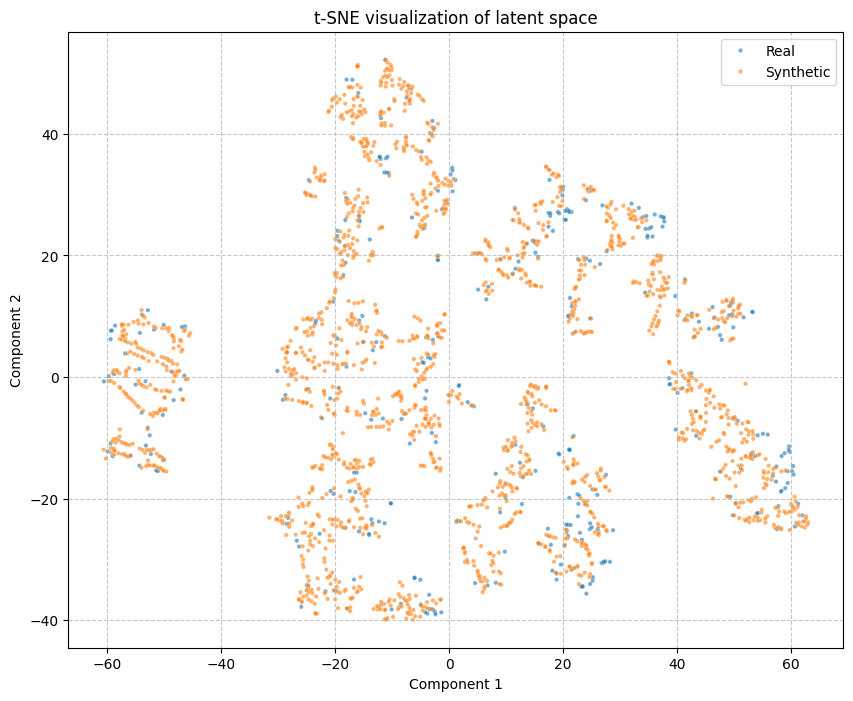

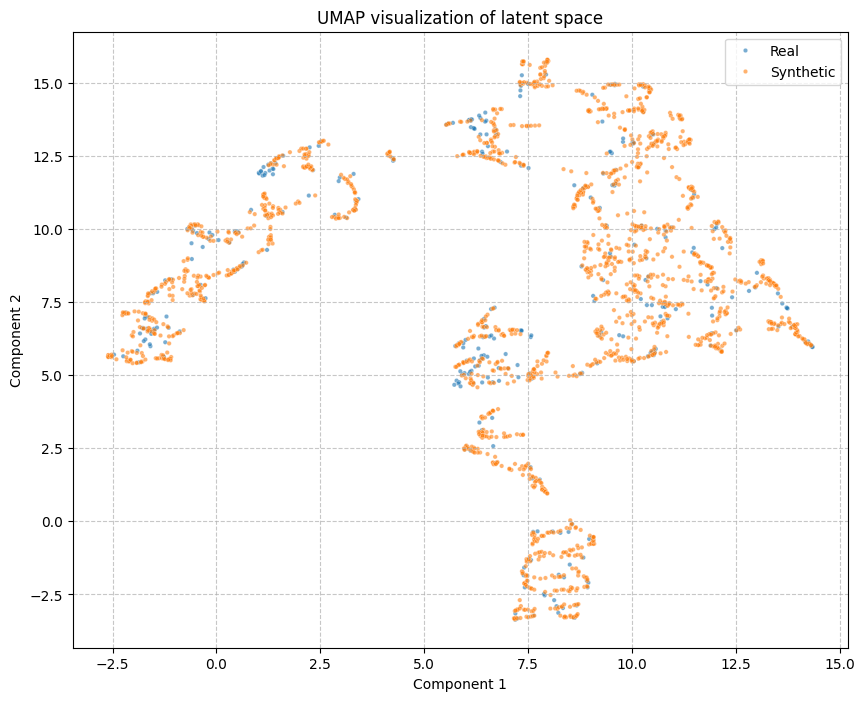

In [ ]:
"""t-SNE/UMAP"""

import seaborn as sns
from sklearn.manifold import TSNE
import umap

if isinstance(real_latents, torch.Tensor):
    real_latents = real_latents.cpu().numpy()
if isinstance(synth_latents, torch.Tensor):
    synth_latents = synth_latents.cpu().numpy()

# 1. Combine Latents and Create Labels
all_latents= np.vstack((real_latents, synth_latents))
labels     = ['Real'] * len(real_latents) + ['Synthetic'] * len(synth_latents)
labels_np  = np.array(labels) # Convert labels to np (easier indexing)

# 2. Apply t-SNE
# n_components: 2 for 2D plot, 3 for 3D plot
# perplexity: controls balance between local and global aspects of data (often 5-50)
# n_iter: number of iterations for optimization
tsne_results = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
print("t-SNE done.")

# 3. Apply UMAP
# n_neighbors: balances local vs. global structure (smaller for local, larger for global)
# min_dist: controls how tightly points are packed together
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(all_latents)
print("UMAP done.")

# 4. Plotting
def plot_latent_space(embedding, labels, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels,
                    palette=['#1f77b4', '#ff7f0e'], s=10, alpha=0.6, legend='full')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_latent_space(tsne_results, labels_np, 't-SNE visualization of latent space')
plot_latent_space(umap_results, labels_np, 'UMAP visualization of latent space')

# # To make 3D plots, set n_components=3
# from mpl_toolkits.mplot3d import Axes3D
# def plot_latent_space_3d(embedding, labels, title):
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     colors = {'Real': '#1f77b4', 'Synthetic': '#ff7f0e'}
#     for label_val in np.unique(labels):
#         idx = (labels == label_val)
#         ax.scatter(embedding[idx, 0], embedding[idx, 1], embedding[idx, 2],
#                    color=colors[label_val], label=label_val, s=10, alpha=0.6)
#     ax.set_title(title)
#     ax.set_xlabel('Component 1')
#     ax.set_ylabel('Component 2')
#     ax.set_zlabel('Component 3')
#     ax.legend()
#     plt.show()
# tsne_results_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
# umap_results_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(all_latents)
# plot_latent_space_3d(tsne_results_3d, labels_np, 't-SNE 3D Visualization of Latent Space')
# plot_latent_space_3d(umap_results_3d, labels_np, 'UMAP 3D Visualization of Latent Space')
